In [1]:
# Do not change this cell

import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchinfo import summary

import matplotlib.pyplot as plt
from timeit import default_timer as timer

import numpy as np

random_seed = 1
torch.manual_seed(random_seed)
np.random.seed(random_seed)

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

trainset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=ToTensor()
)
validationset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=ToTensor()
)
testset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=ToTensor()
)
classes = trainset.classes

valid_size = 0.2
train_length = len(trainset)
indices = list(range(len(trainset)))
split = int(np.floor(valid_size * train_length))

np.random.shuffle(indices)

train_idx=indices[split:]
valid_idx=indices[:split]
train_sampler=SubsetRandomSampler(train_idx)
validation_sampler=SubsetRandomSampler(valid_idx)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, sampler=train_sampler)
valid_loader = DataLoader(trainset, batch_size=batch_size, sampler=validation_sampler)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

print(f"Length of train data loader: {len(train_loader)} batches of {batch_size}")
print(f"Length of validation data loader: {len(valid_loader)} batches of {batch_size}")
print(f"Length of test data loader: {len(test_loader)} batches of {batch_size}")

# Check out what is inside the training data loader
train_features_batch, train_label_batch = next(iter(train_loader))
print(train_features_batch.shape, train_label_batch.shape)

C:\Users\18183\anaconda3\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Length of train data loader: 188 batches of 256
Length of validation data loader: 47 batches of 256
Length of test data loader: 40 batches of 256
torch.Size([256, 1, 28, 28]) torch.Size([256])


In [2]:
# Do not change this cell
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

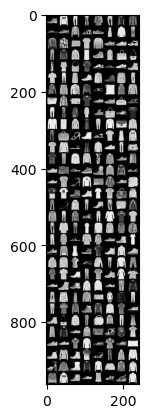

In [3]:
# Do not change this cell
dataiter = iter(test_loader)
images, labels = next(dataiter)
# Show images
imshow(torchvision.utils.make_grid(images))

In [60]:
# TODO: you will design your model here
class ConvModel(nn.Module):
#         # TODO: complete this method
    def __init__(self, input_size, output_size):
        super(ConvModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=320, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=320, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, output_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # TODO: complete this method
        x = torch.nn.functional.relu(self.conv1(x))
        x = torch.nn.functional.max_pool2d(x, kernel_size=2, stride=2)
        x = torch.nn.functional.relu(self.conv2(x))
        x = torch.nn.functional.max_pool2d(x, kernel_size=2, stride=2)
        x = x.view(-1, 64 * 7 * 7)
        x = torch.nn.functional.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [61]:
def train_step(model, train_loader, loss_fn, optimizer, reg_param, device):
    # TODO: implement one epoch of training
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        reg_loss = 0.0
        for param in model.parameters():
            reg_loss += torch.norm(param, p=2)
        loss += reg_param * reg_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_loss = total_loss / len(train_loader)
    train_accuracy = correct / total
    return train_loss, train_accuracy

In [62]:
def evaluation_step(model, data_loader, loss_fn, reg_param, device):
    # TODO: implement evaluation on a data set, data_loader 
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            reg_loss = 0.0
            for param in model.parameters():
                reg_loss += torch.norm(param, p=2)
            loss += reg_param * reg_loss
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    eval_loss = total_loss / len(data_loader)
    eval_accuracy = correct / total
    return eval_loss, eval_accuracy

In [63]:
def train_conv_model(train_loader, valid_loader, test_loader, random_seed):
    # Make device
    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda"
    else:
        if torch.backends.mps.is_available():
            device = "mps"

    torch.manual_seed(random_seed)  # do not change this

    # TODO: write codes to train your model here
    model = ConvModel(input_size=1, output_size=10)
    
    #prediction_loss = nn.CrossEntropyLoss()
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#     loss = custom_loss(prediction_loss, model, 0.001)
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()
    
    epochs = 11
    model.to(device)
    train_losses, train_accuracies = [], []
    valid_losses, valid_accuracies = [], []
    test_losses, test_accuracies = [], []
    
    for epoch in range(epochs):
        train_loss, train_accuracy = train_step(model, train_loader, loss_fn, optimizer, reg_param=0.001, device=device)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        
        valid_loss, valid_accuracy = evaluation_step(model, valid_loader, loss_fn, reg_param=0.001, device=device)
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_accuracy)
        
        test_loss, test_accuracy = evaluation_step(model, test_loader, loss_fn, reg_param=0.001, device=device)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)
        
        print(f"Epoch {epoch+1}/{epochs}:"
              f" Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f},"
              f" Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_accuracy:.4f},"
              f" Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}")
    
    return model, train_losses, train_accuracies, valid_losses, valid_accuracies, test_losses, test_accuracies
    

In [64]:
def plot_accuracy_performance(train_accuracies, valid_accuracies, test_accuracies):
   # TODO: plot accuracy curves, you can reuse your codes from the simple classification task 
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(test_accuracies, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Performance')
    plt.legend()
    plt.show()


In [65]:
#train_losses
#test_losses

In [66]:
def plot_loss_performance(train_losses, valid_accuracies, test_losses):
# TODO: plot loss curves, you can reuse your codes from the simple classification task
    #train_losses = [loss.detach().numpy() for loss in train_losses]
    #valid_losses = [loss.detach().numpy() for loss in valid_accuracies]
    #test_losses = [loss.detach().numpy() for loss in test_losses]
    
    plt.plot(train_losses, label='Train Loss')
    plt.plot(valid_losses, label='Validation Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training, Validation, and Test Loss')
    plt.legend()
    plt.show()

In [67]:
def test_loss(prediction_loss, model, reg_param):
    reg_loss = 0.0
    for param in model.parameters():
        reg_loss += torch.norm(param, p=2)
    loss = prediction_loss + reg_param * reg_loss
    return loss

In [68]:
# Do not change this cell
random_seed = 1
model, train_losses, train_accuracies, valid_losses, valid_accuracies, test_losses, test_accuracies\
= train_conv_model(train_loader, valid_loader, test_loader, random_seed)

Epoch 1/11: Train Loss: 0.7110, Train Acc: 0.7523, Valid Loss: 0.4110, Valid Acc: 0.8588, Test Loss: 0.4262, Test Acc: 0.8533
Epoch 2/11: Train Loss: 0.4560, Train Acc: 0.8488, Valid Loss: 0.3734, Valid Acc: 0.8763, Test Loss: 0.3889, Test Acc: 0.8711
Epoch 3/11: Train Loss: 0.4052, Train Acc: 0.8687, Valid Loss: 0.3355, Valid Acc: 0.8901, Test Loss: 0.3537, Test Acc: 0.8820
Epoch 4/11: Train Loss: 0.3700, Train Acc: 0.8808, Valid Loss: 0.3131, Valid Acc: 0.8975, Test Loss: 0.3285, Test Acc: 0.8933
Epoch 5/11: Train Loss: 0.3515, Train Acc: 0.8877, Valid Loss: 0.3028, Valid Acc: 0.9015, Test Loss: 0.3180, Test Acc: 0.8968
Epoch 6/11: Train Loss: 0.3328, Train Acc: 0.8967, Valid Loss: 0.3083, Valid Acc: 0.9005, Test Loss: 0.3257, Test Acc: 0.8950
Epoch 7/11: Train Loss: 0.3169, Train Acc: 0.9014, Valid Loss: 0.2864, Valid Acc: 0.9103, Test Loss: 0.3052, Test Acc: 0.9029
Epoch 8/11: Train Loss: 0.3040, Train Acc: 0.9065, Valid Loss: 0.2842, Valid Acc: 0.9127, Test Loss: 0.3011, Test Acc:

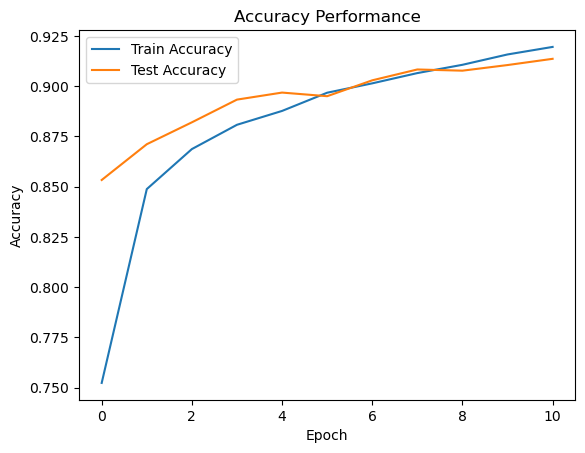

In [69]:
# Do not change this cell
plot_accuracy_performance(train_accuracies, valid_accuracies, test_accuracies)

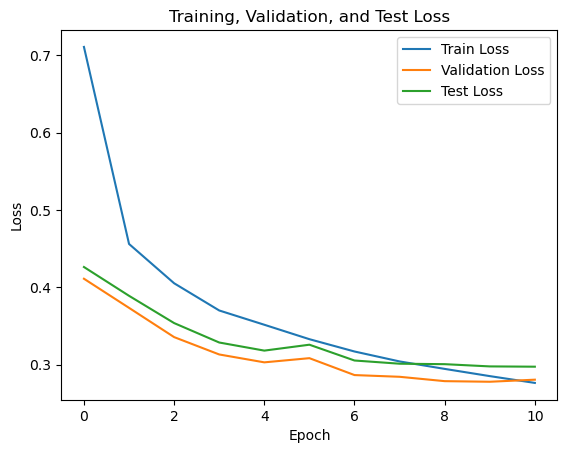

In [70]:
# Do not change this cell
plot_loss_performance(train_losses, valid_losses, test_losses)